# I'll Cry in Another Walk-In
## Tracking Quit Rates in Accommodation and Food Services

**Series:** JTS720000000000000QUR - Quits Rate, Accommodation and Food Services (NAICS 72)  
**Period:** January 2016 - August 2026  
**Author:** Jason Staats  
**Updated:** October 2026

In [1]:
# --- Core ---
import requests
import json
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.stattools import acf

# --- Time Series ---
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

# --- Plot Styling ---
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.family'] = 'sans-serif'

API_KEY = "Your Key Here"
url = "https://api.bls.gov/publicAPI/v2/timeseries/data/"

payload = {
    "seriesid": ["JTS720000000000000QUR"],
    "startyear": "2016",
    "endyear": "2026",
    "registrationkey": API_KEY
}

response = requests.post(url, json=payload)

print("Status:", response.status_code)

if response.status_code != 200:
    raise RuntimeError(
        f"BLS request failed ({response.status_code}): {response.text}"
    )

else:
    data = response.json()

    if data.get('status') != 'REQUEST_SUCCEEDED':
        raise RuntimeError(f"BLS API error: {data.get('message')}")    
    records = []

    for item in data['Results']['series'][0]['data']:
        if item['period'].startswith('M'):
            records.append({
                "year": int(item['year']),
                "month": int(item['period'][1:]),
                "quit_rate": float(item['value'])
            })

df = pd.DataFrame(records).sort_values(['year', 'month'])


df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df = df.set_index('date')
df = df.drop(columns=['year', 'month'])
df = df.loc[:'2026-08-01'].copy()
expected_dates = pd.date_range('2016-01-01', '2026-08-01', freq='MS')

if not df.index.equals(expected_dates):
    raise ValueError("Dates contain missing, duplicate, or unexpected months.")

df.index.freq = 'MS'
df.tail(8)

Status: 200


,quit_rate
date,
2026-01-01,4.7
2026-02-01,4.1
2026-03-01,4.2
2026-04-01,4.0
2026-05-01,4.2
2026-06-01,4.1
2026-07-01,3.7
2026-08-01,3.5


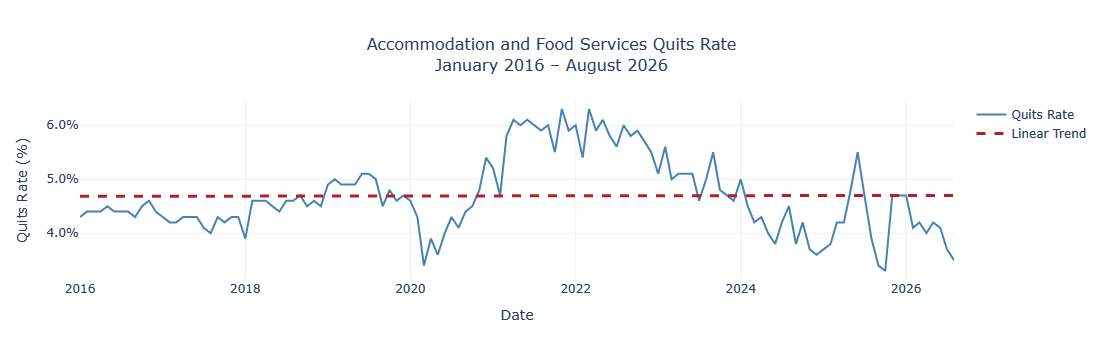

In [2]:
# =============================================================================
# Section 2: Full Series
# =============================================================================

# Create numeric index for regression
x_numeric = np.arange(len(df))

# Fit linear regression
slope, intercept = np.polyfit(x_numeric, df['quit_rate'], 1)

# Generate trend values
trend_line = slope * x_numeric + intercept

fig = go.Figure()

# Original series
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['quit_rate'],
    mode='lines',
    name='Quits Rate',
    line=dict(color='steelblue', width=2)
))

# Linear trend line
fig.add_trace(go.Scatter(
    x=df.index,
    y=trend_line,
    mode='lines',
    name='Linear Trend',
    line=dict(color='firebrick', width=3, dash='dash')
))

fig.update_layout(
    title=dict(
        text='Accommodation and Food Services Quits Rate<br>January 2016 – August 2026',
        x=0.5,
        font=dict(size=16)
    ),
    xaxis_title='Date',
    yaxis_title='Quits Rate (%)',
    yaxis=dict(
        ticksuffix='%',
        tickformat='.1f'
    ),
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

## Full Series

Much like Up or On the Rocks, it's worth clarifying what this series is actually measuring. The JOLTS quits rate counts voluntary separations during the month as a percentage of employment. A worker who chooses to leave is a quit. Someone who gets laid off is not. That distinction matters here because the quits rate measures voluntary departures, which can offer insight into workers' willingness to leave their jobs without directly measuring their reasons for doing so.

This series covers accommodation and food services and is published by BLS on a seasonally adjusted basis. BLS makes that adjustment before the data is retrieved. No additional seasonal adjustment is applied in this notebook.

Quit rates held relatively steady between 2016 and 2019, averaging around 4.5%. A sharp decline followed in early 2020, with rates recovering toward pre-pandemic levels later that year.

From mid-2021 through early 2022, quit rates remained elevated, fluctuating around 6% and staying well above the pre-pandemic range. Rates have trended down since, with dips below pre-pandemic levels appearing by late 2024. Volatility increased considerably in 2025, when the quits rate moved across a range of more than two percentage points.

Through August 2026, month-to-month swings have moderated compared with 2025, although quit rates have continued to decline. August recorded 3.5%, down 0.2 percentage points from July's 3.7% and below the 2016–2019 range of 3.9% to 5.1%. August's reading is among the lowest in the full dataset.

The linear trend line stays near 4.7% across the full period, but that nearly flat slope masks substantial changes over time. The pandemic-era increase has reversed, and recent observations now fall below the pre-pandemic range. From 2025 through August 2026, observed rates span 3.3% to 5.5%, compared with 3.9% to 5.1% during 2016–2019. These descriptive comparisons alone cannot establish whether the underlying baseline has changed.

*Note: JOLTS data comes from a survey of business establishments and is subject to revision as additional responses are received and annual updates are applied.*

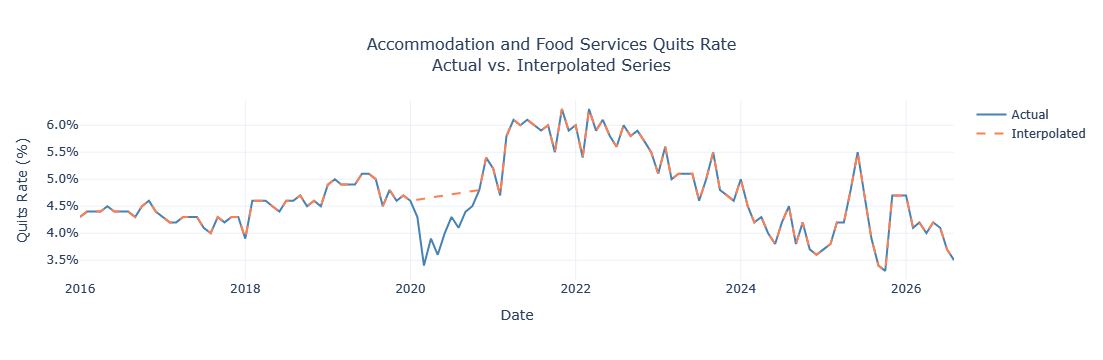

In [3]:
# =============================================================================
# COVID Interpolation
# =============================================================================

df_raw = df.copy()
df_interp = df.copy()
df_interp.loc['2020-02-01':'2020-10-01', 'quit_rate'] = np.nan
df_interp['quit_rate'] = df_interp['quit_rate'].interpolate(method='time')

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_raw.index, y=df_raw['quit_rate'],
    mode='lines', name='Actual',
    line=dict(color='steelblue', width=2),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.1f}%' for v in df_raw['quit_rate']]
))

fig.add_trace(go.Scatter(
    x=df_interp.index, y=df_interp['quit_rate'],
    mode='lines', name='Interpolated',
    line=dict(color='coral', width=2, dash='dash'),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.1f}%' for v in df_interp['quit_rate']]
))

fig.update_layout(
    title=dict(text='Accommodation and Food Services Quits Rate<br>Actual vs. Interpolated Series',
               x=0.5, font=dict(size=16)),
    xaxis_title='Date',
    yaxis_title='Quits Rate (%)',
    yaxis=dict(
        tickvals=[v / 10 for v in range(10, 75, 5)],
        ticktext=[f'{v / 10:.1f}%' for v in range(10, 75, 5)]
    ),
    hovermode='x unified',
    template='plotly_white'
)

fig.show()

## COVID-19 Interpolation

Quit rates fell sharply during the initial pandemic disruption in early 2020. Because the goal of the subsequent analysis is to examine longer-term trends, remaining seasonality, and persistence, this abrupt movement could influence the patterns identified.

To reduce that influence, quit rate values from February through October 2020 were replaced using time-based linear interpolation between the January and November 2020 observations. This creates a smooth transition across those nine months.

This is a modeling choice that replaces actual observed variation with an assumed path through the disruption. It does not reconstruct what quit rates would have been without the pandemic, and its effect on forecast accuracy has not been evaluated against a model using the original observations.

The original BLS series is shown alongside the interpolated version above for transparency. All subsequent analysis uses the interpolated series, with observations outside the February–October 2020 window unchanged.

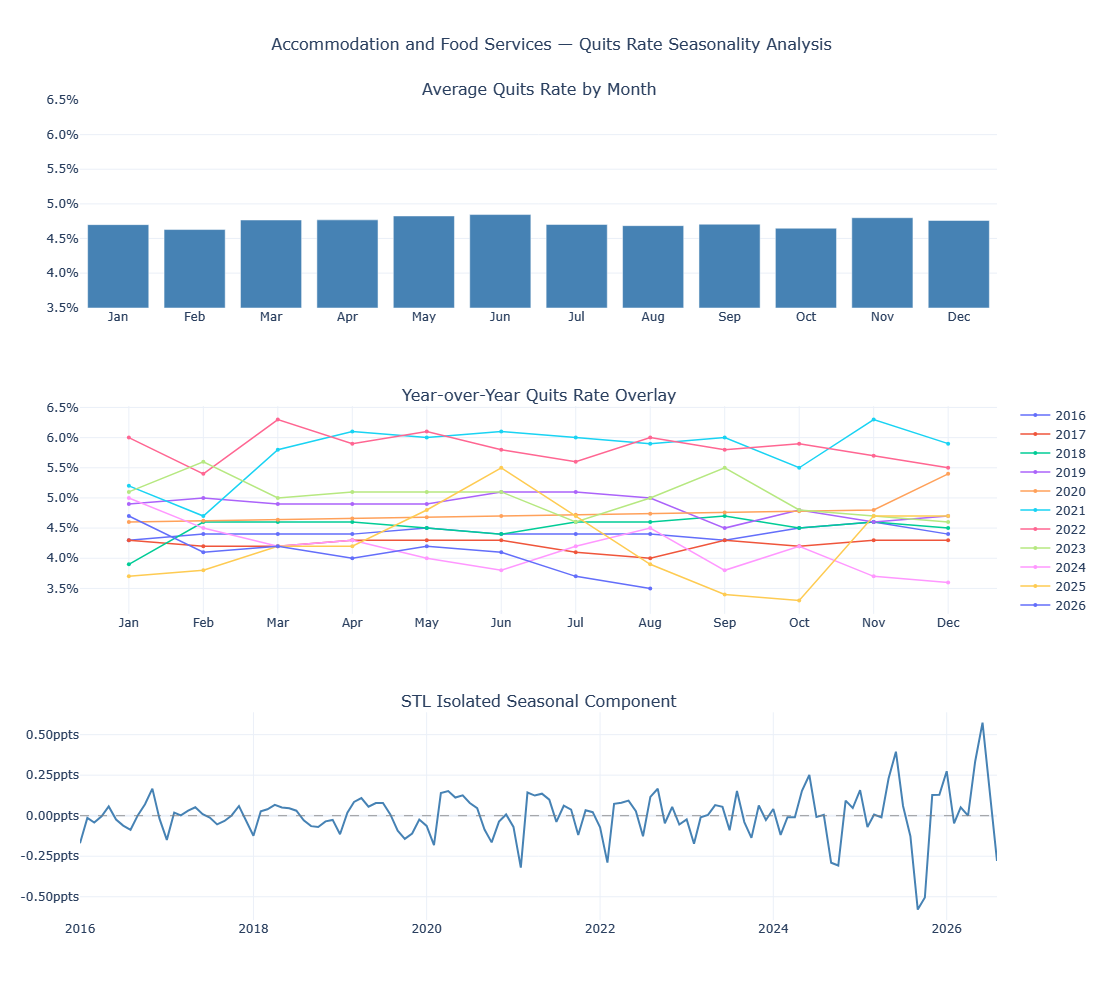

In [4]:
# =============================================================================
# Section 3: Seasonality Analysis
# =============================================================================
df_interp['month'] = df_interp.index.month
df_interp['year'] = df_interp.index.year
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

# STL fit
stl = STL(df_interp['quit_rate'], period=12)
stl_fit = stl.fit()
df_interp['seasonal'] = stl_fit.seasonal

monthly_avg = df_interp.groupby('month')['quit_rate'].mean().reset_index()

fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=('Average Quits Rate by Month',
                    'Year-over-Year Quits Rate Overlay',
                    'STL Isolated Seasonal Component'),
    vertical_spacing=0.12
)

# --- Plot 1: Monthly Average Bar ---
fig.add_trace(go.Bar(
    x=month_labels,
    y=monthly_avg['quit_rate'],
    marker_color='steelblue',
    name='Monthly Average',
    showlegend=False,
    hovertemplate='%{x}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in monthly_avg['quit_rate']]
), row=1, col=1)

fig.update_yaxes(
    range=[3.5, 6.5],
    tickvals=[3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5],
    ticktext=[f'{v:.1f}%' for v in [3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5]],
    row=1, col=1
)

# --- Plot 2: Year-over-Year Overlay ---
colors = px.colors.qualitative.Plotly
for i, (year, group) in enumerate(df_interp.groupby('year')):
    group = group.sort_values('month')
    fig.add_trace(go.Scatter(
        x=month_labels[:len(group)],
        y=group['quit_rate'],
        mode='lines+markers',
        name=str(year),
        line=dict(color=colors[i % len(colors)], width=1.5),
        marker=dict(size=4),
        hovertemplate=f'{year} %{{x}}: %{{customdata}}<extra></extra>',
        customdata=[f'{v:.1f}%' for v in group['quit_rate']]
    ), row=2, col=1)

fig.update_yaxes(
    tickvals=[3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5],
    ticktext=[f'{v:.1f}%' for v in [3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5]],
    row=2, col=1
)

# --- Plot 3: STL Seasonal Component ---
fig.add_trace(go.Scatter(
    x=df_interp.index,
    y=df_interp['seasonal'],
    mode='lines',
    name='Seasonal Component',
    showlegend=False,
    line=dict(color='steelblue', width=2),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.3f} ppts' for v in df_interp['seasonal']]
), row=3, col=1)

fig.add_hline(y=0, line_dash='dash', line_color='gray', line_width=0.8, row=3, col=1)

seasonal_ticks = [-0.50, -0.25, 0.00, 0.25, 0.50]
fig.update_yaxes(
    tickvals=seasonal_ticks,
    ticktext=[f'{v:.2f}ppts' for v in seasonal_ticks],
    row=3, col=1
)

fig.update_layout(
    title=dict(text='Accommodation and Food Services — Quits Rate Seasonality Analysis',
               x=0.5, font=dict(size=16)),
    height=1000,
    template='plotly_white',
    hovermode='closest',
    showlegend=True,
    legend=dict(
        x=1.02,
        y=0.50,
        xanchor='left',
        yanchor='middle'
    )
)

fig.show()

## Seasonality

BLS publishes this quits-rate series on a seasonally adjusted basis, so this analysis examines whether a recurring annual pattern remains after that adjustment. Monthly averages across the full period are relatively similar, with only modest differences between months. These averages alone do not establish whether those differences recur consistently from year to year.

January through August averages include 2026 observations, while September through December averages end in 2025.

The year-over-year overlay shows more pronounced differences in the overall level of quits than in a shared seasonal pattern. Rates in 2021 and 2022 were noticeably higher than those in 2016 through 2019. More recent observations have returned toward the pre-pandemic range, with some months falling below it.

The STL seasonal component is generally small relative to the broader movements in the series, although its fluctuations become larger near the end of the sample. Those recent movements warrant caution when describing the remaining seasonality as uniformly weak.

Taken together, these charts show limited evidence of a stable remaining annual pattern and support evaluating nonseasonal forecasting models. They do not, by themselves, establish whether adding seasonal terms would improve forecast accuracy.

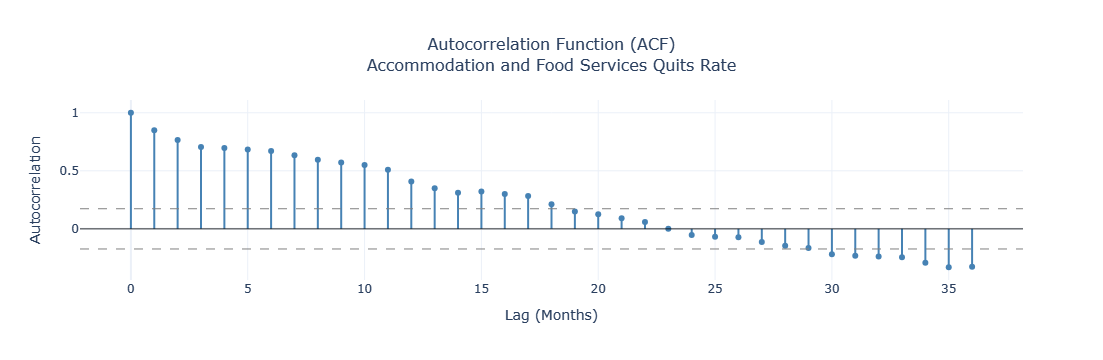

In [5]:
# =============================================================================
# Section 4: ACF
# =============================================================================
acf_values = acf(df_interp['quit_rate'], nlags=36)
lags = list(range(len(acf_values)))

fig = go.Figure()

# Zero line
fig.add_hline(y=0, line_color='black', line_width=0.8)

# 95% confidence interval bounds
n = len(df_interp['quit_rate'])
ci_bound = 1.96 / np.sqrt(n)
fig.add_hline(y=ci_bound, line_dash='dash', line_color='gray', line_width=1)
fig.add_hline(y=-ci_bound, line_dash='dash', line_color='gray', line_width=1)

# ACF stems
for i, (lag, val) in enumerate(zip(lags, acf_values)):
    fig.add_trace(go.Scatter(
        x=[lag, lag],
        y=[0, val],
        mode='lines',
        line=dict(color='steelblue', width=2),
        showlegend=False,
        hoverinfo='skip'
    ))

# ACF points
fig.add_trace(go.Scatter(
    x=lags,
    y=acf_values,
    mode='markers',
    marker=dict(color='steelblue', size=6),
    name='ACF',
    showlegend=False,
    hovertemplate='Lag %{x}: %{y:.3f}<extra></extra>'
))

fig.update_layout(
    title=dict(text='Autocorrelation Function (ACF)<br>Accommodation and Food Services Quits Rate',
               x=0.5, font=dict(size=16)),
    xaxis_title='Lag (Months)',
    yaxis_title='Autocorrelation',
    template='plotly_white',
    hovermode='closest'
)

fig.show()

## Autocorrelation

The autocorrelation function shows how closely quit rates relate to their past values at different monthly lags.

The ACF generally declines as the lag increases, remaining positive through lag 22, reaching approximately zero at lag 23, and becoming negative afterward. This pattern indicates substantial persistence, meaning that periods of relatively high or low quit rates tend to carry forward into subsequent months. Because the ACF is calculated on the level series, however, the gradual decline may reflect both serial dependence and longer-term movement rather than a specific autoregressive structure.

There is no distinct peak at lag 12 relative to neighboring lags. Such a peak can indicate an annual pattern, although its absence alone does not rule out seasonality. Since BLS already seasonally adjusts this series, the relevant question is whether annual dependence remains after that adjustment.

Taken together with the earlier seasonality analysis, the ACF shows substantial persistence and limited evidence of a strong remaining annual pattern. This supports evaluating nonseasonal forecasting models, while leaving their performance to be assessed through validation.

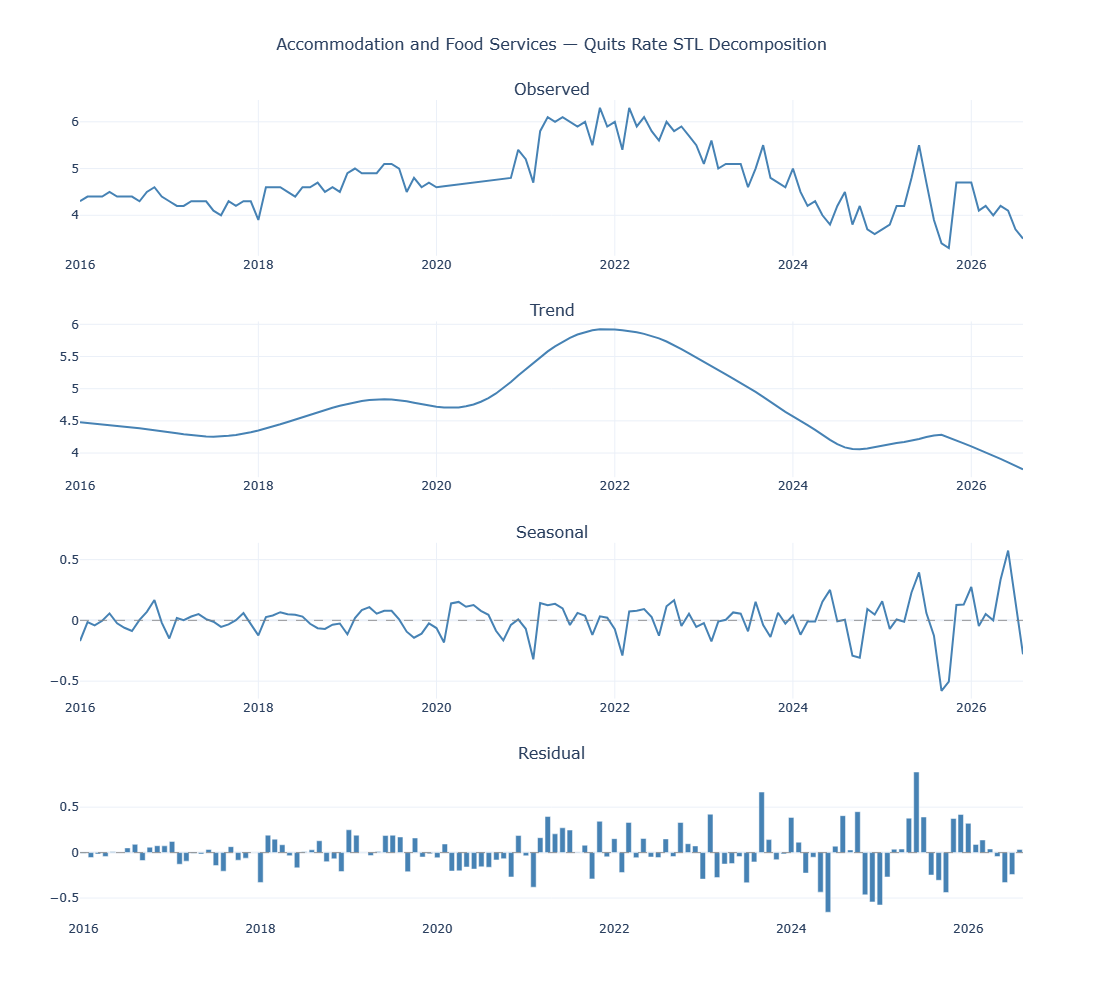

In [6]:
# =============================================================================
# Section 5: Full STL Decomposition
# =============================================================================
trend = stl_fit.trend
seasonal = stl_fit.seasonal
residual = stl_fit.resid

fig = make_subplots(
    rows=4, cols=1,
    subplot_titles=('Observed', 'Trend', 'Seasonal', 'Residual'),
    vertical_spacing=0.08
)

# --- Observed ---
fig.add_trace(go.Scatter(
    x=df_interp.index, y=df_interp['quit_rate'],
    mode='lines', name='Observed',
    line=dict(color='steelblue', width=2),
    showlegend=False,
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.1f}%' for v in df_interp['quit_rate']]
), row=1, col=1)

# --- Trend ---
fig.add_trace(go.Scatter(
    x=df_interp.index, y=trend,
    mode='lines', name='Trend',
    line=dict(color='steelblue', width=2),
    showlegend=False,
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in trend]
), row=2, col=1)

# --- Seasonal ---
fig.add_trace(go.Scatter(
    x=df_interp.index, y=seasonal,
    mode='lines', name='Seasonal',
    line=dict(color='steelblue', width=2),
    showlegend=False,
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.3f} ppts' for v in seasonal]
), row=3, col=1)

fig.add_hline(y=0, line_color='gray', line_width=0.8, line_dash='dash', row=3, col=1)

# --- Residual ---
fig.add_trace(go.Bar(
    x=df_interp.index, y=residual,
    name='Residual',
    marker_color='steelblue',
    showlegend=False,
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.3f} ppts' for v in residual]
), row=4, col=1)

fig.add_hline(y=0, line_color='gray', line_width=0.8, line_dash='dash', row=4, col=1)

fig.update_layout(
    title=dict(text='Accommodation and Food Services — Quits Rate STL Decomposition',
               x=0.5, font=dict(size=16)),
    height=1000,
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

## STL Decomposition

STL decomposition separates a time series into trend, seasonal, and residual components. The trend captures gradual changes in the level of the series. The seasonal component estimates recurring movements using a specified 12-month period. The residual contains the variation left after the estimated trend and seasonal components are removed.

The trend component captures the longer arc of the data. It shows relative stability through the pre-pandemic period, a smooth transition through the interpolated window, and a climb to an elevated period around 2021 and 2022. A broad decline follows, interrupted by a modest rise during 2025 before the trend turns downward again into August 2026. By the end of the sample, the estimated trend is below its pre-pandemic levels.

Because BLS already seasonally adjusts this series, the STL seasonal component represents remaining calendar-related variation estimated by the decomposition. Its movements are generally small relative to the broader changes in the series, although they become larger near the end of the sample. This component alone does not establish that a stable annual pattern remains.

Most residual values are relatively close to zero, although larger deviations appear during periods of greater month-to-month movement, particularly in 2025. These residuals describe variation left unexplained by the decomposition. They are not forecast errors.

The observed panel reflects the interpolated series. The smooth transition from February through October 2020 results from replacing the original observations, rather than actual recorded quit activity. Trend and seasonal estimates near the end of the sample may also change as additional observations become available.

In [7]:
# =============================================================================
# Section 6: Forecasting
# =============================================================================

# --- Train/Validation Split ---
train = df_interp[df_interp.index < '2025-01-01']['quit_rate']
validation = df_interp[(df_interp.index >= '2025-01-01') & 
                (df_interp.index < '2026-01-01')]['quit_rate']

train.index = pd.DatetimeIndex(train.index, freq='MS')
validation.index = pd.DatetimeIndex(validation.index, freq='MS')

print(f"Training observations: {len(train)}")
print(f"Validation observations: {len(validation)}")

Training observations: 108
Validation observations: 12


In [8]:
# --- Model 1: ETS ---
# Seasonal component omitted based on limited annual seasonality
ets_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
).fit(optimized=True)

ets_forecast = ets_model.forecast(12)


# --- Model 2: ARIMA Candidate Comparison ---
# Compare several nonseasonal specifications using validation MAE
arima_orders = [
    (0, 1, 1),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2)
]

arima_results = []
arima_models = {}
arima_forecasts = {}

for order in arima_orders:
    model = SARIMAX(
        train,
        order=order,
        seasonal_order=(0, 0, 0, 0)
    ).fit(disp=False)

    forecast = model.forecast(12)
    mae = mean_absolute_error(validation, forecast)

    arima_results.append({
        'Order': order,
        'MAE': mae,
        'AIC': model.aic
    })

    arima_models[order] = model
    arima_forecasts[order] = forecast

arima_results = pd.DataFrame(arima_results).sort_values('MAE')

best_order = arima_results.iloc[0]['Order']
arima_model = arima_models[best_order]
arima_forecast = arima_forecasts[best_order]


# --- Model 3: Naive ---
naive_forecast = pd.Series(
    [train.iloc[-1]] * 12,
    index=validation.index
)


# --- Model 4: OLS with Trend and Seasonal Dummies ---
def build_ols_features(series):
    df_ols = pd.DataFrame({'quit_rate': series})
    df_ols['trend'] = range(len(df_ols))

    for m in range(1, 12):
        df_ols[f'month_{m}'] = (
            df_ols.index.month == m
        ).astype(int)

    return df_ols


train_ols = build_ols_features(train)

X_train = train_ols.drop(columns='quit_rate')
y_train = train_ols['quit_rate']

ols_model = LinearRegression().fit(X_train, y_train)

future_ols = pd.DataFrame(
    {'trend': range(len(train), len(train) + 12)},
    index=validation.index
)

for m in range(1, 12):
    future_ols[f'month_{m}'] = (
        future_ols.index.month == m
    ).astype(int)

ols_forecast = pd.Series(
    ols_model.predict(future_ols),
    index=validation.index
)


# --- Results ---
print("ARIMA Candidate Validation Results")
print(
    arima_results.to_string(
        index=False,
        formatters={
            'MAE': '{:.3f}'.format,
            'AIC': '{:.3f}'.format
        }
    )
)

print(f"\nSelected ARIMA order: {best_order}")

arima_name = f"ARIMA{best_order}".replace(" ", "")

models = {
    'ETS': ets_forecast,
    arima_name: arima_forecast,
    'Naive': naive_forecast,
    'OLS': ols_forecast
}

print("\nModel Validation MAE (January - December 2025)")
print("-" * 50)

for name, forecast in models.items():
    mae = mean_absolute_error(validation, forecast)
    print(f"{name:20s}: {mae:.3f} ppts")

ARIMA Candidate Validation Results
    Order   MAE    AIC
(0, 1, 1) 0.637 32.775
(1, 1, 1) 0.647 34.288
(2, 1, 1) 0.648 35.766
(1, 1, 0) 0.705 37.186
(1, 1, 2) 0.725 32.099

Selected ARIMA order: (0, 1, 1)

Model Validation MAE (January - December 2025)
--------------------------------------------------
ETS                 : 1.037 ppts
ARIMA(0,1,1)        : 0.637 ppts
Naive               : 0.725 ppts
OLS                 : 1.045 ppts


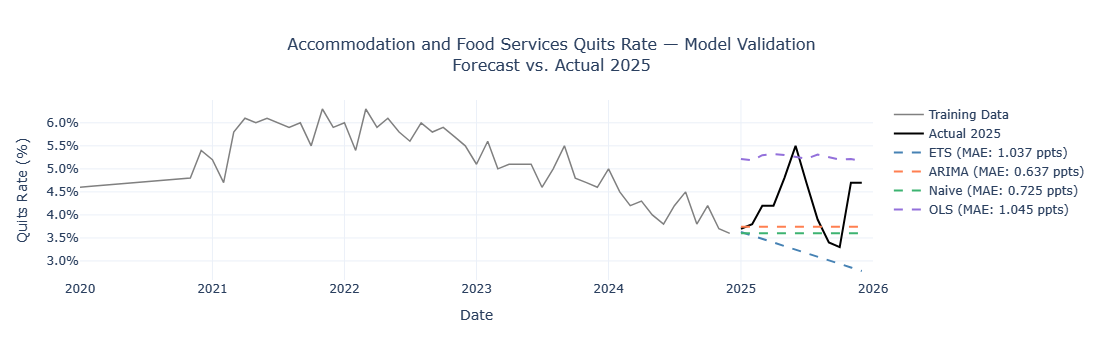

In [9]:
# --- Validation Plot ---
fig = go.Figure()

# Actual training data
fig.add_trace(go.Scatter(
    x=train.index, y=train.values,
    mode='lines', name='Training Data',
    line=dict(color='gray', width=1.5),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in train.values]
))

# Actual validation data
fig.add_trace(go.Scatter(
    x=validation.index, y=validation.values,
    mode='lines', name='Actual 2025',
    line=dict(color='black', width=2),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in validation.values]
))

# ETS forecast
fig.add_trace(go.Scatter(
    x=validation.index, y=ets_forecast.values,
    mode='lines', name=f'ETS (MAE: {mean_absolute_error(validation, ets_forecast):.3f} ppts)',
    line=dict(color='steelblue', width=2, dash='dash'),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in ets_forecast.values]
))

# ARIMA forecast
fig.add_trace(go.Scatter(
    x=validation.index, y=arima_forecast.values,
    mode='lines', name=f'ARIMA (MAE: {mean_absolute_error(validation, arima_forecast):.3f} ppts)',
    line=dict(color='coral', width=2, dash='dash'),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in arima_forecast.values]
))

# Naive forecast
fig.add_trace(go.Scatter(
    x=validation.index, y=naive_forecast.values,
    mode='lines', name=f'Naive (MAE: {mean_absolute_error(validation, naive_forecast):.3f} ppts)',
    line=dict(color='mediumseagreen', width=2, dash='dash'),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in naive_forecast.values]
))

# OLS forecast
fig.add_trace(go.Scatter(
    x=validation.index, y=ols_forecast.values,
    mode='lines', name=f'OLS (MAE: {mean_absolute_error(validation, ols_forecast):.3f} ppts)',
    line=dict(color='mediumpurple', width=2, dash='dash'),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in ols_forecast.values]
))

fig.update_layout(
    title=dict(text='Accommodation and Food Services Quits Rate — Model Validation<br>Forecast vs. Actual 2025',
               x=0.5, font=dict(size=16)),
    xaxis_title='Date',
    yaxis_title='Quits Rate (%)',
    yaxis=dict(
        tickvals=[v / 10 for v in range(20, 70, 5)],
        ticktext=[f'{v / 10:.1f}%' for v in range(20, 70, 5)]
    ),
    template='plotly_white',
    hovermode='x unified',
    xaxis=dict(range=['2020-01-01', '2026-01-01'])
)

fig.show()

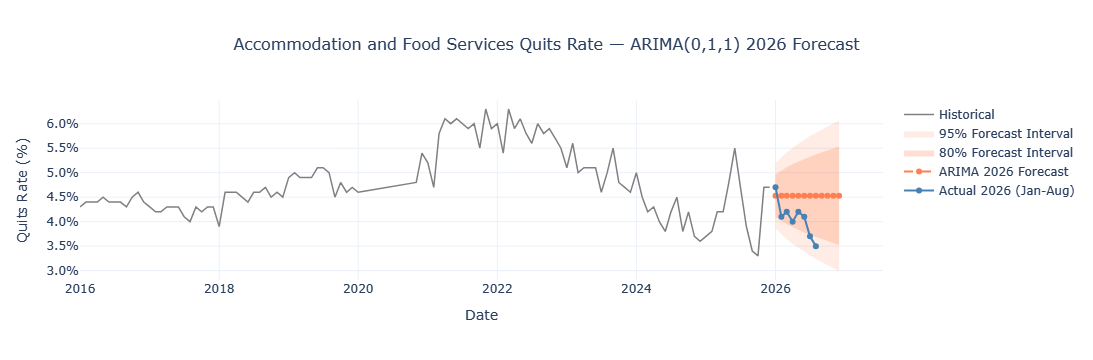

In [10]:
# --- Forward Forecast: 2026 ---
# Retrain ARIMA on full series through Dec 2025
full_series = df_interp[df_interp.index < '2026-01-01']['quit_rate']
full_series.index = pd.DatetimeIndex(full_series.index, freq='MS')

arima_final = SARIMAX(
    full_series,
    order=(0, 1, 1),
    seasonal_order=(0, 0, 0, 0)
).fit(disp=False)

forecast_index = pd.date_range(start='2026-01-01', periods=12, freq='MS')

forecast_result = arima_final.get_forecast(12)
arima_2026 = forecast_result.predicted_mean
arima_2026.index = forecast_index

ci_80 = forecast_result.conf_int(alpha=0.20)
ci_95 = forecast_result.conf_int(alpha=0.05)
ci_80.index = forecast_index
ci_95.index = forecast_index

fig = go.Figure()

# Historical series
fig.add_trace(go.Scatter(
    x=full_series.index, y=full_series.values,
    mode='lines', name='Historical',
    line=dict(color='gray', width=1.5),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in full_series.values]
))

# 95% CI band
fig.add_trace(go.Scatter(
    x=pd.concat([ci_95.index.to_series(), ci_95.index.to_series()[::-1]]),
    y=pd.concat([ci_95.iloc[:, 1], ci_95.iloc[:, 0][::-1]]),
    fill='toself', fillcolor='rgba(255,127,80,0.15)',
    line=dict(width=0), showlegend=True, name='95% Forecast Interval'
))

# 80% CI band
fig.add_trace(go.Scatter(
    x=pd.concat([ci_80.index.to_series(), ci_80.index.to_series()[::-1]]),
    y=pd.concat([ci_80.iloc[:, 1], ci_80.iloc[:, 0][::-1]]),
    fill='toself', fillcolor='rgba(255,127,80,0.25)',
    line=dict(width=0), showlegend=True, name='80% Forecast Interval'
))

# 2026 forecast
fig.add_trace(go.Scatter(
    x=arima_2026.index, y=arima_2026.values,
    mode='lines+markers', name='ARIMA 2026 Forecast',
    line=dict(color='coral', width=2, dash='dash'),
    marker=dict(size=6),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in arima_2026.values]
))

# Actual Jan-Aug 2026 for immediate validation
actual_2026 = df_interp[df_interp.index >= '2026-01-01']['quit_rate']
fig.add_trace(go.Scatter(
    x=actual_2026.index, y=actual_2026.values,
    mode='lines+markers', name='Actual 2026 (Jan-Aug)',
    line=dict(color='steelblue', width=2),
    marker=dict(size=6),
    hovertemplate='%{x|%b %Y}: %{customdata}<extra></extra>',
    customdata=[f'{v:.2f}%' for v in actual_2026.values]
))

fig.update_layout(
    title=dict(text='Accommodation and Food Services Quits Rate — ARIMA(0,1,1) 2026 Forecast',
               x=0.5, font=dict(size=16)),
    xaxis_title='Date',
    yaxis_title='Quits Rate (%)',
    yaxis=dict(
        tickvals=[v / 10 for v in range(10, 75, 5)],
        ticktext=[f'{v / 10:.1f}%' for v in range(10, 75, 5)]
    ),
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

## Forecasting

January through December 2025 was held back as a validation set. Four forecasting approaches were trained on January 2016 through December 2024 and used to forecast the following 12 months. The OLS model includes a linear time trend and month indicators. Their predictions were compared against observed 2025 values using mean absolute error, measured in percentage points. Several nonseasonal ARIMA specifications were compared, with ARIMA(0,1,1) producing the lowest validation error.

| **Model** | **MAE** |
| --- | --- |
| ETS | 1.037 ppts |
| ARIMA(0,1,1) | 0.637 ppts |
| Naive | 0.725 ppts |
| OLS | 1.045 ppts |

ARIMA(0,1,1) produced the lowest MAE at 0.637 percentage points, compared with 0.725 percentage points for the Naive model. The Naive model simply carries forward the final training observation. Its second-place finish shows that this simple approach provided a competitive benchmark in the 2025 validation period.

Because the 2025 results were used to select the ARIMA specification, they represent model-selection performance rather than an independent final test of the selected model. The ranking reflects performance over this particular year and does not establish that ARIMA will perform best in every forecasting period.

None of the evaluated models captured the timing and magnitude of the 2025 swings. Quit rates rose to 5.5% in June before falling sharply later in the year. ARIMA and Naive produced flat forecasts, ETS projected a decline, and OLS remained above most observed values. ARIMA achieved the lowest average error without reproducing the year's month-to-month movements.

ARIMA(0,1,1) was then retrained on the interpolated series through December 2025 to generate a January–December 2026 forecast with 80% and 95% prediction intervals. The model was not updated with the observed 2026 values. Its point forecast is flat at approximately 4.53%, a feature of this specification without a drift term.

Actual quit rates were below the point forecast in every month from February through August 2026. August's rate of 3.5% was approximately 1.03 percentage points below the forecast. It fell below the 80% prediction interval of 3.69% to 5.37%, but remained inside the 95% interval of 3.24% to 5.82%. July's rate of 3.7% also fell below its corresponding 80% interval while remaining inside its 95% interval.

These prediction intervals describe uncertainty under the fitted model and its assumptions. Remaining within the wider interval does not establish that the forecast is tracking the decline well. The sustained overprediction shows that the fixed forecast has not captured the recent downward movement. As additional observations become available, they can be compared with this forecast to assess how its performance changes.